In [7]:
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1c"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df["N_features"] = df["features"].str.extract(r"RFE_(\d+)_permute")

In [8]:
val_df = df[df.dataset == "val"]
dmm_val_df = val_df[val_df.ref == "DMM"]
dmm_val_df.N_features = dmm_val_df.N_features.astype("int")

## Only tested NON-multiheaded, `best_RFE` multimodal. Not sure about data extent (full training or only the previous training set?)

In [17]:
dmm_val_df[dmm_val_df.context == "multimodal"].features.unique()

array(['best_RFE_35_permute', 'best_RFE_30_permute',
       'best_RFE_25_permute', 'best_RFE_45_permute',
       'best_RFE_40_permute', 'best_RFE_10_permute',
       'best_RFE_15_permute', 'best_RFE_20_permute', 'best_RFE_5_permute',
       'best_RFE_50_permute'], dtype=object)

In [18]:
dmm_val_df

,dataset,ref,model,samples,context,features,n_hidden,depth,multiheaded,dropout_rate,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse,N_features
3551,val,DMM,EGFR_MAPK__logobs,HCC1500,multimodal,best_RFE_35_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,1.0,500.0,3.0,0.806778,35
3550,val,DMM,EGFR_MAPK__logobs,HCC1500,multimodal,best_RFE_35_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,0.0,500.0,3.0,1.629731,35
3549,val,DMM,EGFR_MAPK__logobs,HCC1500,multimodal,best_RFE_30_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,9.0,500.0,3.0,0.416976,30
3548,val,DMM,EGFR_MAPK__logobs,HCC1500,multimodal,best_RFE_30_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,8.0,500.0,3.0,0.500352,30
3547,val,DMM,EGFR_MAPK__logobs,HCC1500,multimodal,best_RFE_30_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,7.0,500.0,3.0,0.321514,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4431,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_45_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,1.0,500.0,3.0,0.567350,45
4430,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_45_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,0.0,500.0,3.0,2.045757,45
4428,val,DMM,EGFR_MAPK__logobs,MCF7,proteomics,HVGRFE_40_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,8.0,500.0,3.0,2.207201,40
2660,val,DMM,EGFR_MAPK__logobs,BT20,cytof_init,RFE_10_permute,2.0,0.0,False,0.0,0.01,0.0,0.0001,200.0,0.0,500.0,3.0,0.612027,10


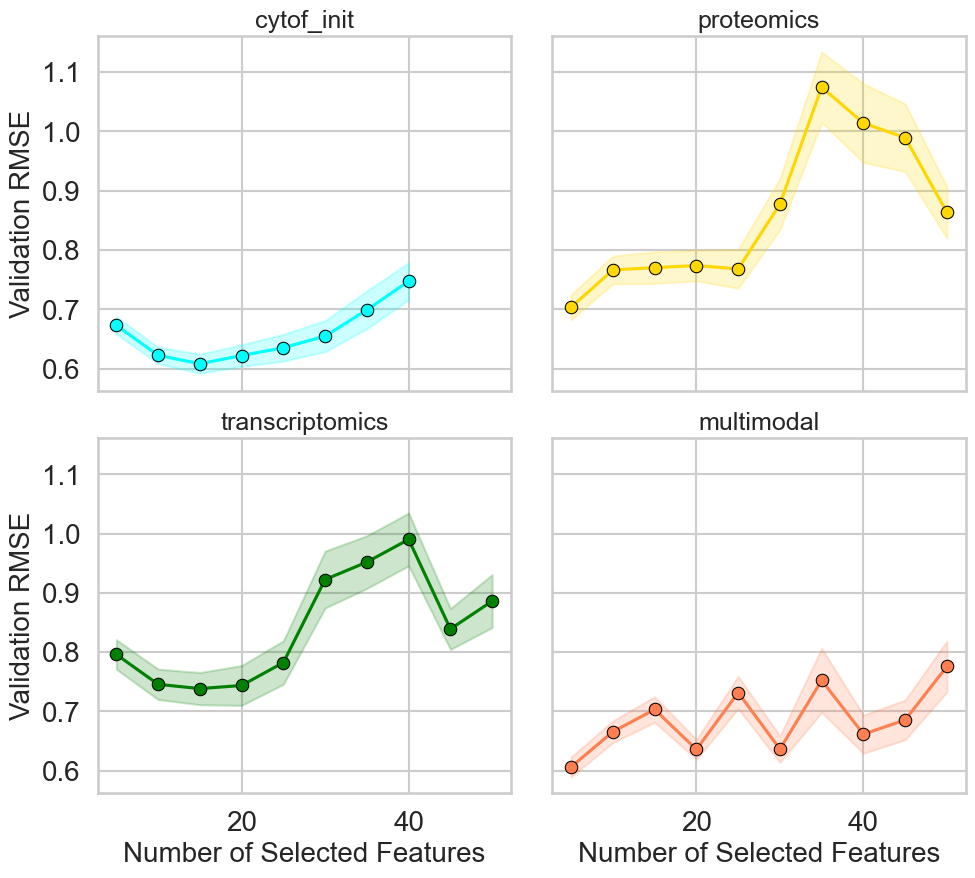

In [9]:
import matplotlib.pyplot as plt
# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "coral",
}

g = sns.FacetGrid(
    dmm_val_df,
    col="context",
    col_order=palette.keys(),
    col_wrap=2,
    sharey=True,
    despine=False,
    height=5,
)

g.map_dataframe(
    sns.lineplot,
    x="N_features",
    y="rmse",
    marker='o',
    hue="context",
    palette=palette,
    mec="black",
    errorbar="se"
)

# Add axis labels and titles
g.set_axis_labels("Number of Selected Features", "Validation RMSE", fontsize=20)
g.set_titles(col_template="{col_name}", fontsize=20)

# Enlarge tick labels
for ax in g.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=20)


# Adjust layout
plt.subplots_adjust(top=0.85, wspace=0.10)
plt.show()

In [19]:
dmm_val_df[dmm_val_df.context == "cytof_init"].groupby("features").rmse.mean()

features
RFE_10_permute    0.622322
RFE_15_permute    0.608058
RFE_20_permute    0.621913
RFE_25_permute    0.635095
RFE_30_permute    0.654673
RFE_35_permute    0.698883
RFE_40_permute    0.747291
RFE_5_permute     0.672848
Name: rmse, dtype: float64

## By comparing cytof with RFE_10_permute with the same from `v69_fig1b_p38`, I can conclude these models were likely trained on the full training dataset (fully comparable) -> potential benefit in increasing the number of features to 15. Fine with increasing features to 15 for `transcriptomics` as well, but very sceptical in reducing to 5 for `proteomics` and `multimodal` - Dropout should address that?!

In [11]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [14]:
kruskal_wallis_groups(
    dmm_val_df,
    "rmse",
    "N_features",
    "context"
)

Context/Group: multimodal - Kruskal-Wallis H-test: H-statistic=26.71, p-value=0.0016, significant? True
Context/Group: cytof_init - Kruskal-Wallis H-test: H-statistic=19.86, p-value=0.0059, significant? True
Context/Group: proteomics - Kruskal-Wallis H-test: H-statistic=46.21, p-value=0.0000, significant? True
Context/Group: transcriptomics - Kruskal-Wallis H-test: H-statistic=49.86, p-value=0.0000, significant? True


Not significant for cytof_init or transcriptomics. multimodal only gets worse. proteomics is the only context where there seems to be an honest and significant benefit in using more features - is it just that feature selection cannot find relevant features at all and this increases the chances of finding remotely useful ones?